Loaded:
 - outputs_baseline/panel_df_with_unemp_s.csv
 - outputs_baseline/baseline_df.csv
 - outputs_baseline/baseline_weights.csv

Treatment start: 2011-04-01
Derived trperiod: 424
Complete-case states: 46
Donor count: 45
Predictor count: 13

Baseline reference metrics
 baseline_pre_rmspe  baseline_topo_h1_wasserstein_31  trperiod  embed_dim  embed_delay
           0.196901                         1.197383       424          3            1

Running lambda = 0.00

Running lambda = 0.10

Running lambda = 0.25

Running lambda = 0.50

Running lambda = 1.00

Running lambda = 2.00

=== TOPOLOGY-AUGMENTED GRID SUMMARY ===
 lambda  success                               status  objective_value  pre_rmspe  pre_rmspe_ratio_to_baseline  topo_h1_wasserstein_31  topo_ratio_to_baseline  l1_weight_change_from_baseline  effective_donors_gt_1e_4
   0.00     True         baseline SCM solution reused         1.000000   0.196901                     1.000000                1.197383                1.000000 

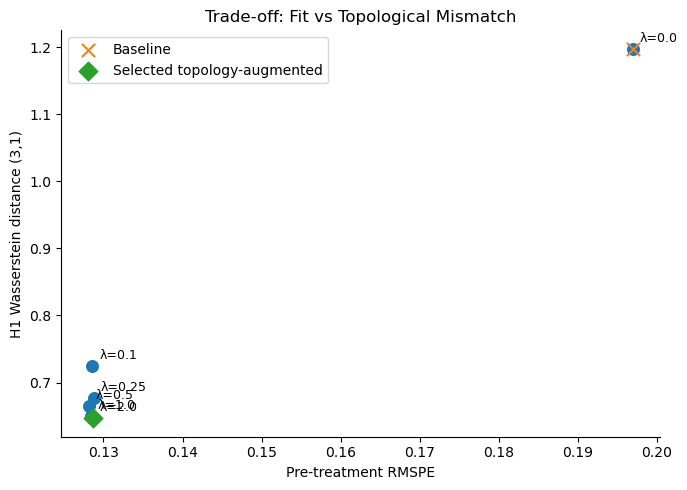

Saved figure: outputs_topology_augmented/topology_augmented_lambda_paths.pdf


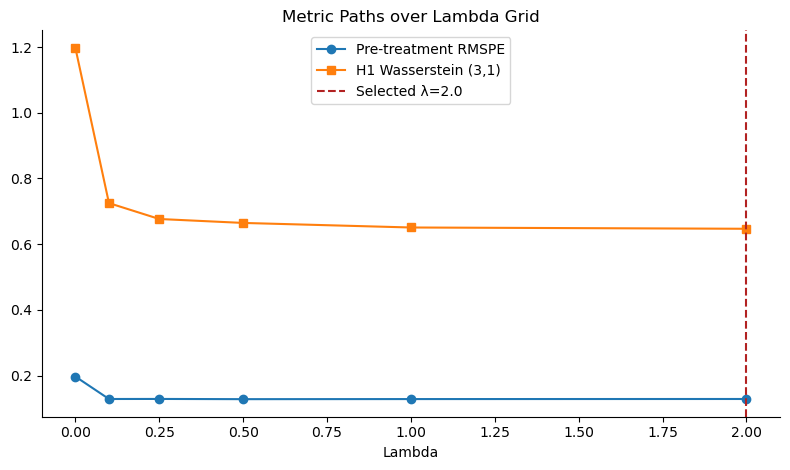

Saved figure: outputs_topology_augmented/topology_augmented_weight_comparison.pdf


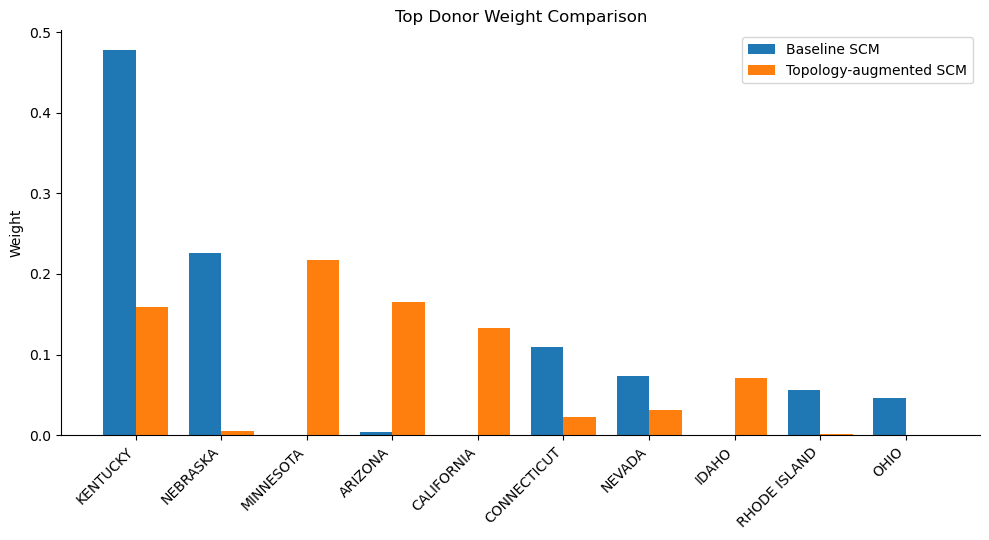

Saved figure: outputs_topology_augmented/baseline_vs_topology_augmented_paths.pdf


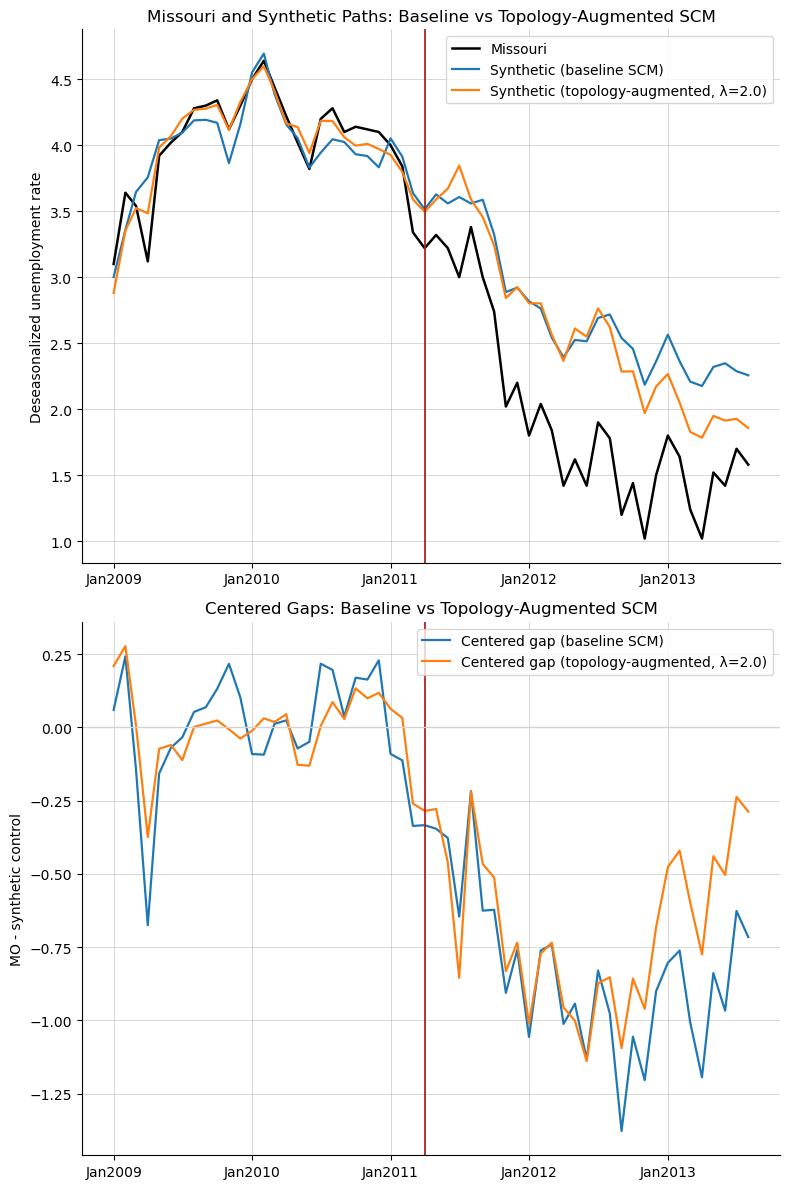


=== BASELINE VS TOPOLOGY-AUGMENTED PRE / POST / RATIO ===
            method  lambda treatment_start  n_pre  n_post  pre_rmspe  post_rmspe  post_pre_ratio
          baseline     0.0      2011-04-01     27      29   0.193063    0.862722         4.46861
topology_augmented     2.0      2011-04-01     27      29   0.128232    0.719162         5.60828

=== ENRICHED BASELINE VS TOPOLOGY-AUGMENTED METRICS ===
            method  lambda  pre_rmspe  topo_h1_wasserstein_31 treatment_start  n_pre  n_post  post_rmspe  post_pre_ratio
          baseline     0.0   0.196901                1.197383      2011-04-01     27      29    0.862722         4.46861
topology_augmented     2.0   0.128638                0.646785      2011-04-01     27      29    0.719162         5.60828
Saved figure: outputs_topology_augmented/pre_treatment_standardized_path_comparison.pdf


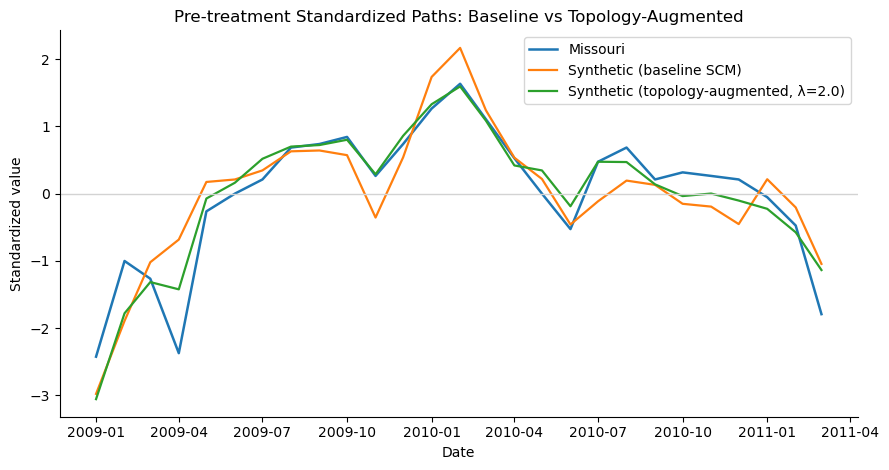


Saved outputs in: outputs_topology_augmented
 - baseline_weights_aligned.csv
 - baseline_reference_metrics.csv
 - topology_augmented_grid_summary.csv
 - selected_lambda.json
 - topology_augmented_selected_weights.csv
 - topology_augmented_df.csv
 - baseline_vs_topology_augmented_metrics.csv
 - baseline_vs_topology_augmented_prepost_metrics.csv
 - topology_augmented_tradeoff_scatter.pdf
 - topology_augmented_lambda_paths.pdf
 - baseline_vs_topology_augmented_weights.csv
 - topology_augmented_weight_comparison.pdf
 - baseline_vs_topology_augmented_paths.csv
 - baseline_vs_topology_augmented_paths.pdf
 - pre_treatment_standardized_path_comparison.csv
 - pre_treatment_standardized_path_comparison.pdf


In [3]:
# ============================================================
# 06_topology_augmented_scm
# Revised version:
#   - optimize donor weights W on the donor simplex
#   - objective = scaled pre-RMSPE + lambda * scaled H1 Wasserstein
#   - main topology specification only: embedding (3,1)
#   - SAVE:
#       * baseline_vs_topology_augmented_prepost_metrics.csv
#       * enriched baseline_vs_topology_augmented_metrics.csv
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from ripser import ripser
from persim import wasserstein

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
INPUT_DIR = "outputs_baseline"
OUTPUT_DIR = "outputs_topology_augmented"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PANEL_PATH = os.path.join(INPUT_DIR, "panel_df_with_unemp_s.csv")
BASELINE_DF_PATH = os.path.join(INPUT_DIR, "baseline_df.csv")
BASELINE_W_PATH = os.path.join(INPUT_DIR, "baseline_weights.csv")

# ------------------------------------------------------------
# 1) Settings
# ------------------------------------------------------------
TREATMENT_START = pd.Timestamp("2011-04-01")
TREATED_STATE = "MISSOURI"

DROP_STATES = {"FLORIDA", "ARKANSAS", "MICHIGAN", "SOUTH CAROLINA", "GEORGIA"}

ANCHOR_STATIC = 409
ANCHOR_UNEMP = [397, 401, 405, 409, 413, 417, 421]
STATIC_COLS = ["pct_rural", "Chg1999_2006", "Chg2007_2010", "p12", "p_naics3", "p_naics4"]

# Main topology specification
EMBED_DIM = 3
EMBED_DELAY = 1

# Lambda grid
LAMBDA_GRID = [0.00, 0.10, 0.25, 0.50, 1.00, 2.00]

# Selection rule:
# among lambdas with pre-RMSPE <= baseline_pre_RMSPE * RMSPE_TOL_MULT,
# choose the one with the smallest H1 Wasserstein.
RMSPE_TOL_MULT = 1.25

# ------------------------------------------------------------
# 2) Helpers
# ------------------------------------------------------------
def save_fig(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")

def load_series_csv(path):
    tmp = pd.read_csv(path)
    if tmp.shape[1] < 2:
        raise ValueError(f"Cannot parse series-like csv: {path}")
    idx = tmp.iloc[:, 0].astype(str)
    vals = pd.to_numeric(tmp.iloc[:, 1], errors="coerce")
    s = pd.Series(vals.values, index=idx.values)
    return s

def zscore(x):
    x = np.asarray(x, dtype=float)
    s = x.std(ddof=0)
    if s == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / s

def delay_embed(x, dim=3, delay=1):
    x = np.asarray(x, dtype=float)
    n = len(x) - (dim - 1) * delay
    if n <= 0:
        raise ValueError(
            f"Series too short for requested embedding: len={len(x)}, dim={dim}, delay={delay}"
        )
    return np.column_stack([x[i:i+n] for i in range(0, dim * delay, delay)])

def h1_wasserstein_from_series(seq1, seq2, dim=3, delay=1):
    s1 = zscore(seq1)
    s2 = zscore(seq2)

    cloud1 = delay_embed(s1, dim=dim, delay=delay)
    cloud2 = delay_embed(s2, dim=dim, delay=delay)

    dgm1 = ripser(cloud1, maxdim=1)["dgms"][1]
    dgm2 = ripser(cloud2, maxdim=1)["dgms"][1]

    if len(dgm1) > 0:
        dgm1 = dgm1[np.isfinite(dgm1[:, 1])]
    if len(dgm2) > 0:
        dgm2 = dgm2[np.isfinite(dgm2[:, 1])]

    if len(dgm1) == 0 and len(dgm2) == 0:
        return 0.0

    return float(wasserstein(dgm1, dgm2))

def pre_rmspe(Z1, Z0, w):
    gap = Z1 - Z0 @ w
    return float(np.sqrt(np.mean(gap ** 2)))

def topology_augmented_objective(
    w, Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam
):
    fit = pre_rmspe(Z1, Z0, w)
    synthetic_pre = Z0 @ w
    topo = h1_wasserstein_from_series(
        Z1, synthetic_pre, dim=EMBED_DIM, delay=EMBED_DELAY
    )

    fit_scaled = fit / (baseline_pre_rmspe + 1e-12)
    topo_scaled = topo / (baseline_topo_dist + 1e-12)

    return fit_scaled + lam * topo_scaled

def optimize_topology_augmented_w(
    Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam, w0
):
    J = Z0.shape[1]

    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * J

    def obj(w):
        return topology_augmented_objective(
            w, Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam
        )

    res = minimize(
        obj,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 120, "ftol": 1e-6, "disp": False}
    )

    if not res.success:
        res = minimize(
            obj,
            w0,
            method="SLSQP",
            bounds=bounds,
            constraints=cons,
            options={"maxiter": 200, "ftol": 1e-7, "disp": False}
        )

    return res

def rmspe_from_series(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x ** 2)))

# ------------------------------------------------------------
# 3) Load data
# ------------------------------------------------------------
panel_df = pd.read_csv(PANEL_PATH)
panel_df["date"] = pd.to_datetime(panel_df["date"])

baseline_df = pd.read_csv(BASELINE_DF_PATH)
baseline_df["date"] = pd.to_datetime(baseline_df["date"])

baseline_w_series = load_series_csv(BASELINE_W_PATH)

print("Loaded:")
print(" -", PANEL_PATH)
print(" -", BASELINE_DF_PATH)
print(" -", BASELINE_W_PATH)

# ------------------------------------------------------------
# 4) Build sample used in baseline SCM
# Keep the same complete-case state filtering logic as baseline
# ------------------------------------------------------------
synth_df = panel_df.loc[~panel_df["state"].isin(DROP_STATES)].copy()
synth_df = synth_df[(synth_df["mo_yr"] >= 397) & (synth_df["mo_yr"] <= 452)].copy()

tr_match = synth_df.loc[synth_df["date"] == TREATMENT_START, "mo_yr"].drop_duplicates()
if len(tr_match) != 1:
    raise ValueError(
        f"Expected exactly one mo_yr for treatment_start={TREATMENT_START.date()}, got {tr_match.tolist()}"
    )
trperiod = int(tr_match.iloc[0])

print("\nTreatment start:", TREATMENT_START.date())
print("Derived trperiod:", trperiod)

static_block = (
    synth_df.loc[synth_df["mo_yr"] == ANCHOR_STATIC, ["state"] + STATIC_COLS]
    .drop_duplicates(subset=["state"])
    .set_index("state")
)

dyn_block = (
    synth_df.loc[synth_df["mo_yr"].isin(ANCHOR_UNEMP), ["state", "mo_yr", "unemp_s"]]
    .pivot(index="state", columns="mo_yr", values="unemp_s")
)
dyn_block.columns = [f"unemp_s_{c}" for c in dyn_block.columns]

X_full = static_block.join(dyn_block, how="inner").sort_index()

pre_panel = (
    synth_df.loc[synth_df["mo_yr"] < trperiod, ["state", "mo_yr", "unemp_s"]]
    .pivot(index="mo_yr", columns="state", values="unemp_s")
    .sort_index()
)

x_complete = X_full.dropna().index.tolist()
z_complete = pre_panel.columns[~pre_panel.isna().any(axis=0)].tolist()
common_states = sorted(set(x_complete).intersection(z_complete))

X_full = X_full.loc[common_states]
pre_panel = pre_panel[common_states]

if TREATED_STATE not in common_states:
    raise ValueError("MISSOURI not found in complete-case sample.")

donor_states = [s for s in common_states if s != TREATED_STATE]
predictor_names = X_full.columns.tolist()

print("Complete-case states:", len(common_states))
print("Donor count:", len(donor_states))
print("Predictor count:", len(predictor_names))

Z1 = pre_panel[TREATED_STATE].values.astype(float)
Z0 = pre_panel[donor_states].values.astype(float)

# ------------------------------------------------------------
# 5) Align baseline W
# ------------------------------------------------------------
baseline_w = baseline_w_series.reindex(donor_states).fillna(0.0).values.astype(float)
if baseline_w.sum() <= 0:
    raise ValueError("Aligned baseline donor weights sum to zero.")
baseline_w = baseline_w / baseline_w.sum()

pd.Series(baseline_w, index=donor_states).to_csv(
    os.path.join(OUTPUT_DIR, "baseline_weights_aligned.csv")
)

# ------------------------------------------------------------
# 6) Baseline reference values
# ------------------------------------------------------------
baseline_pre_rmspe = pre_rmspe(Z1, Z0, baseline_w)
baseline_topo_dist = h1_wasserstein_from_series(
    Z1, Z0 @ baseline_w, dim=EMBED_DIM, delay=EMBED_DELAY
)

baseline_ref = pd.DataFrame([{
    "baseline_pre_rmspe": baseline_pre_rmspe,
    "baseline_topo_h1_wasserstein_31": baseline_topo_dist,
    "trperiod": trperiod,
    "embed_dim": EMBED_DIM,
    "embed_delay": EMBED_DELAY
}])
baseline_ref.to_csv(os.path.join(OUTPUT_DIR, "baseline_reference_metrics.csv"), index=False)

print("\nBaseline reference metrics")
print(baseline_ref.to_string(index=False))

# ------------------------------------------------------------
# 7) Run lambda grid
# ------------------------------------------------------------
results = []
weights_dict = {}

current_w0 = baseline_w.copy()

for lam in LAMBDA_GRID:
    print("\n" + "=" * 72)
    print(f"Running lambda = {lam:.2f}")
    print("=" * 72)

    if np.isclose(lam, 0.0):
        w_star = baseline_w.copy()
        success = True
        status_msg = "baseline SCM solution reused"
        objective_value = topology_augmented_objective(
            w_star, Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam
        )
    else:
        res = optimize_topology_augmented_w(
            Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam, current_w0
        )
        success = bool(res.success)
        status_msg = res.message

        if success:
            w_star = res.x.copy()
            w_star = np.clip(w_star, 0.0, 1.0)
            w_star = w_star / w_star.sum()
            objective_value = res.fun
            current_w0 = w_star.copy()
        else:
            print(f"Lambda {lam:.2f} failed: {status_msg}")
            w_star = np.full_like(baseline_w, np.nan)
            objective_value = np.nan

    if success:
        pre_rmspe_val = pre_rmspe(Z1, Z0, w_star)
        topo_val = h1_wasserstein_from_series(
            Z1, Z0 @ w_star, dim=EMBED_DIM, delay=EMBED_DELAY
        )
        l1_change = float(np.sum(np.abs(w_star - baseline_w)))
        effective_donors = int(np.sum(w_star > 1e-4))
    else:
        pre_rmspe_val = np.nan
        topo_val = np.nan
        l1_change = np.nan
        effective_donors = np.nan

    results.append({
        "lambda": lam,
        "success": success,
        "status": status_msg,
        "objective_value": objective_value,
        "pre_rmspe": pre_rmspe_val,
        "pre_rmspe_ratio_to_baseline": pre_rmspe_val / baseline_pre_rmspe if success else np.nan,
        "topo_h1_wasserstein_31": topo_val,
        "topo_ratio_to_baseline": topo_val / baseline_topo_dist if success else np.nan,
        "l1_weight_change_from_baseline": l1_change,
        "effective_donors_gt_1e_4": effective_donors
    })

    if success:
        weights_dict[lam] = pd.Series(w_star, index=donor_states).sort_values(ascending=False)
        weights_dict[lam].to_csv(
            os.path.join(OUTPUT_DIR, f"topology_augmented_weights_lambda_{str(lam).replace('.', 'p')}.csv")
        )

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_DIR, "topology_augmented_grid_summary.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "topology_augmented_grid_summary.txt"), "w", encoding="utf-8") as f:
    f.write(results_df.round(6).to_string(index=False))

print("\n=== TOPOLOGY-AUGMENTED GRID SUMMARY ===")
print(results_df.round(6).to_string(index=False))

# ------------------------------------------------------------
# 8) Select lambda
# Rule:
#   among successful lambdas with pre_rmspe <= baseline * RMSPE_TOL_MULT,
#   choose smallest topo distance
# ------------------------------------------------------------
candidate_df = results_df[
    (results_df["success"] == True) &
    (results_df["pre_rmspe"] <= baseline_pre_rmspe * RMSPE_TOL_MULT)
].copy()

if len(candidate_df) == 0:
    print("\nNo lambda met the RMSPE tolerance rule. Falling back to minimum topology distance among successful lambdas.")
    candidate_df = results_df[results_df["success"] == True].copy()

if len(candidate_df) == 0:
    raise ValueError("No successful lambda solutions were found.")

selected_row = candidate_df.sort_values(
    ["topo_h1_wasserstein_31", "pre_rmspe", "lambda"],
    ascending=[True, True, True]
).iloc[0]

selected_lambda = float(selected_row["lambda"])
selected_weights = weights_dict[selected_lambda].copy()

print("\nSelected lambda:", selected_lambda)
print("Selection rule:")
print(f"  pre_rmspe <= baseline_pre_rmspe * {RMSPE_TOL_MULT}")
print("  then minimize topology H1 Wasserstein")
print("\nSelected row:")
print(selected_row)

with open(os.path.join(OUTPUT_DIR, "selected_lambda.json"), "w", encoding="utf-8") as f:
    json.dump({
        "selected_lambda": selected_lambda,
        "selection_rule": f"pre_rmspe <= baseline_pre_rmspe * {RMSPE_TOL_MULT}, then minimize topo_h1_wasserstein_31"
    }, f, indent=2)

selected_weights.to_csv(os.path.join(OUTPUT_DIR, "topology_augmented_selected_weights.csv"))

# ------------------------------------------------------------
# 9) Construct selected topology-augmented path over full window
# ------------------------------------------------------------
full_wide = (
    synth_df.loc[:, ["state", "mo_yr", "date", "unemp_s"]]
    .pivot_table(index=["mo_yr", "date"], columns="state", values="unemp_s")
    .sort_index()
)

topology_augmented_df = full_wide.reset_index().copy()
topology_augmented_df["synthetic_topology_augmented"] = (
    topology_augmented_df[donor_states].values @ selected_weights.reindex(donor_states).fillna(0.0).values
)
topology_augmented_df["treated"] = topology_augmented_df[TREATED_STATE]
topology_augmented_df["gap_raw_topology_augmented"] = (
    topology_augmented_df["treated"] - topology_augmented_df["synthetic_topology_augmented"]
)

pre_mean_gap_topo = topology_augmented_df.loc[
    topology_augmented_df["mo_yr"] < trperiod, "gap_raw_topology_augmented"
].mean()

topology_augmented_df["gap_centered_topology_augmented"] = (
    topology_augmented_df["gap_raw_topology_augmented"] - pre_mean_gap_topo
)

topology_augmented_df.to_csv(
    os.path.join(OUTPUT_DIR, "topology_augmented_df.csv"),
    index=False
)

# ------------------------------------------------------------
# 10) Baseline vs topology-augmented: preliminary metrics
# (final enriched version will be saved after Section 13.5)
# ------------------------------------------------------------
selected_w_array = selected_weights.reindex(donor_states).fillna(0.0).values

selected_pre_rmspe = pre_rmspe(Z1, Z0, selected_w_array)
selected_topo_dist = h1_wasserstein_from_series(
    Z1, Z0 @ selected_w_array, dim=EMBED_DIM, delay=EMBED_DELAY
)

comparison_df = pd.DataFrame([
    {
        "method": "baseline",
        "lambda": 0.0,
        "pre_rmspe": baseline_pre_rmspe,
        "topo_h1_wasserstein_31": baseline_topo_dist
    },
    {
        "method": "topology_augmented",
        "lambda": selected_lambda,
        "pre_rmspe": selected_pre_rmspe,
        "topo_h1_wasserstein_31": selected_topo_dist
    }
])

print("\n=== BASELINE VS TOPOLOGY-AUGMENTED METRICS (PRELIMINARY) ===")
print(comparison_df.to_string(index=False))

# ------------------------------------------------------------
# 11) Trade-off plots
# ------------------------------------------------------------
successful_df = results_df[results_df["success"] == True].copy()

# scatter tradeoff: pre-RMSPE vs topology distance
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(successful_df["pre_rmspe"], successful_df["topo_h1_wasserstein_31"], s=70)

for _, row in successful_df.iterrows():
    ax.annotate(
        f"λ={row['lambda']}",
        (row["pre_rmspe"], row["topo_h1_wasserstein_31"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

ax.scatter([baseline_pre_rmspe], [baseline_topo_dist], s=90, marker="x", label="Baseline")
ax.scatter([selected_pre_rmspe], [selected_topo_dist], s=90, marker="D", label="Selected topology-augmented")

ax.set_xlabel("Pre-treatment RMSPE")
ax.set_ylabel("H1 Wasserstein distance (3,1)")
ax.set_title("Trade-off: Fit vs Topological Mismatch")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(fig, "topology_augmented_tradeoff_scatter.pdf")
plt.show()

# lambda path plot
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(successful_df["lambda"], successful_df["pre_rmspe"], marker="o", label="Pre-treatment RMSPE")
ax.plot(successful_df["lambda"], successful_df["topo_h1_wasserstein_31"], marker="s", label="H1 Wasserstein (3,1)")
ax.axvline(selected_lambda, color="firebrick", linestyle="--", linewidth=1.5, label=f"Selected λ={selected_lambda}")
ax.set_xlabel("Lambda")
ax.set_title("Metric Paths over Lambda Grid")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(fig, "topology_augmented_lambda_paths.pdf")
plt.show()

# ------------------------------------------------------------
# 12) Weight comparison plot
# ------------------------------------------------------------
baseline_w_series_aligned = pd.Series(baseline_w, index=donor_states)
topo_w_series_aligned = selected_weights.reindex(donor_states).fillna(0.0)

weight_compare = pd.DataFrame({
    "baseline": baseline_w_series_aligned,
    "topology_augmented": topo_w_series_aligned
}).fillna(0.0)

weight_compare["max_weight"] = weight_compare[["baseline", "topology_augmented"]].max(axis=1)
weight_compare["abs_change"] = (weight_compare["baseline"] - weight_compare["topology_augmented"]).abs()
weight_compare = weight_compare.sort_values("max_weight", ascending=False)

weight_compare.to_csv(os.path.join(OUTPUT_DIR, "baseline_vs_topology_augmented_weights.csv"))

top_n = 10
plot_weights = weight_compare.head(top_n).copy()

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(plot_weights))
width = 0.38

ax.bar(x - width/2, plot_weights["baseline"], width=width, label="Baseline SCM")
ax.bar(x + width/2, plot_weights["topology_augmented"], width=width, label="Topology-augmented SCM")

ax.set_xticks(x)
ax.set_xticklabels(plot_weights.index, rotation=45, ha="right")
ax.set_ylabel("Weight")
ax.set_title("Top Donor Weight Comparison")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(fig, "topology_augmented_weight_comparison.pdf")
plt.show()

# ------------------------------------------------------------
# 13) Path comparison plot
# ------------------------------------------------------------
required_baseline_cols = ["mo_yr", "date", "treated", "synthetic_baseline", "gap_centered_baseline"]
missing_baseline_cols = [c for c in required_baseline_cols if c not in baseline_df.columns]
if missing_baseline_cols:
    raise ValueError(f"baseline_df is missing columns: {missing_baseline_cols}")

compare_paths_df = baseline_df[
    ["mo_yr", "date", "treated", "synthetic_baseline", "gap_centered_baseline"]
].merge(
    topology_augmented_df[
        ["mo_yr", "date", "synthetic_topology_augmented", "gap_centered_topology_augmented"]
    ],
    on=["mo_yr", "date"],
    how="left"
)

compare_paths_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_vs_topology_augmented_paths.csv"), index=False)

xticks = pd.to_datetime([
    "2009-01-01",
    "2010-01-01",
    "2011-01-01",
    "2012-01-01",
    "2013-01-01"
])
xlabels = [d.strftime("Jan%Y") for d in xticks]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# levels
ax1.plot(compare_paths_df["date"], compare_paths_df["treated"],
         label="Missouri", color="black", linewidth=1.8)
ax1.plot(compare_paths_df["date"], compare_paths_df["synthetic_baseline"],
         label="Synthetic (baseline SCM)", linewidth=1.6)
ax1.plot(compare_paths_df["date"], compare_paths_df["synthetic_topology_augmented"],
         label=f"Synthetic (topology-augmented, λ={selected_lambda})", linewidth=1.6)
ax1.axvline(TREATMENT_START, color="firebrick", linewidth=1.3)

ax1.set_title("Missouri and Synthetic Paths: Baseline vs Topology-Augmented SCM")
ax1.set_ylabel("Deseasonalized unemployment rate")
ax1.legend()
ax1.grid(True, linewidth=0.5, alpha=0.7)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="x", labelbottom=True)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xlabels)

# centered gaps
ax2.plot(compare_paths_df["date"], compare_paths_df["gap_centered_baseline"],
         label="Centered gap (baseline SCM)", linewidth=1.6)
ax2.plot(compare_paths_df["date"], compare_paths_df["gap_centered_topology_augmented"],
         label=f"Centered gap (topology-augmented, λ={selected_lambda})", linewidth=1.6)
ax2.axvline(TREATMENT_START, color="firebrick", linewidth=1.3)
ax2.axhline(0, color="lightgray", linewidth=1)

ax2.set_title("Centered Gaps: Baseline vs Topology-Augmented SCM")
ax2.set_ylabel("MO - synthetic control")
ax2.legend()
ax2.grid(True, linewidth=0.5, alpha=0.7)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="x", labelbottom=True)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xlabels)

plt.tight_layout()
save_fig(fig, "baseline_vs_topology_augmented_paths.pdf")
plt.show()

# ------------------------------------------------------------
# 13.5) Save pre / post / post-pre ratio metrics
# ------------------------------------------------------------
pre_mask = compare_paths_df["date"] < TREATMENT_START
post_mask = compare_paths_df["date"] >= TREATMENT_START

# baseline centered gap
pre_rmspe_baseline = rmspe_from_series(
    compare_paths_df.loc[pre_mask, "gap_centered_baseline"]
)
post_rmspe_baseline = rmspe_from_series(
    compare_paths_df.loc[post_mask, "gap_centered_baseline"]
)
post_pre_ratio_baseline = post_rmspe_baseline / pre_rmspe_baseline

# topology-augmented centered gap
pre_rmspe_topology_augmented = rmspe_from_series(
    compare_paths_df.loc[pre_mask, "gap_centered_topology_augmented"]
)
post_rmspe_topology_augmented = rmspe_from_series(
    compare_paths_df.loc[post_mask, "gap_centered_topology_augmented"]
)
post_pre_ratio_topology_augmented = (
    post_rmspe_topology_augmented / pre_rmspe_topology_augmented
)

pre_post_ratio_df = pd.DataFrame([
    {
        "method": "baseline",
        "lambda": 0.0,
        "treatment_start": TREATMENT_START.strftime("%Y-%m-%d"),
        "n_pre": int(pre_mask.sum()),
        "n_post": int(post_mask.sum()),
        "pre_rmspe": pre_rmspe_baseline,
        "post_rmspe": post_rmspe_baseline,
        "post_pre_ratio": post_pre_ratio_baseline
    },
    {
        "method": "topology_augmented",
        "lambda": selected_lambda,
        "treatment_start": TREATMENT_START.strftime("%Y-%m-%d"),
        "n_pre": int(pre_mask.sum()),
        "n_post": int(post_mask.sum()),
        "pre_rmspe": pre_rmspe_topology_augmented,
        "post_rmspe": post_rmspe_topology_augmented,
        "post_pre_ratio": post_pre_ratio_topology_augmented
    }
])

pre_post_ratio_df.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_vs_topology_augmented_prepost_metrics.csv"),
    index=False
)

print("\n=== BASELINE VS TOPOLOGY-AUGMENTED PRE / POST / RATIO ===")
print(pre_post_ratio_df.to_string(index=False))

# enrich original metrics file
comparison_df_enriched = comparison_df.merge(
    pre_post_ratio_df[
        ["method", "treatment_start", "n_pre", "n_post", "post_rmspe", "post_pre_ratio"]
    ],
    on="method",
    how="left"
)

comparison_df_enriched.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_vs_topology_augmented_metrics.csv"),
    index=False
)

print("\n=== ENRICHED BASELINE VS TOPOLOGY-AUGMENTED METRICS ===")
print(comparison_df_enriched.to_string(index=False))

# ------------------------------------------------------------
# 14) Pretreatment standardized path comparison
# ------------------------------------------------------------
pre_compare = compare_paths_df.loc[
    compare_paths_df["date"] < TREATMENT_START,
    ["date", "treated", "synthetic_baseline", "synthetic_topology_augmented"]
].copy()

pre_compare["treated_z"] = zscore(pre_compare["treated"])
pre_compare["baseline_z"] = zscore(pre_compare["synthetic_baseline"])
pre_compare["topology_augmented_z"] = zscore(pre_compare["synthetic_topology_augmented"])

pre_compare.to_csv(os.path.join(OUTPUT_DIR, "pre_treatment_standardized_path_comparison.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(pre_compare["date"], pre_compare["treated_z"], label="Missouri", linewidth=1.8)
ax.plot(pre_compare["date"], pre_compare["baseline_z"], label="Synthetic (baseline SCM)", linewidth=1.6)
ax.plot(pre_compare["date"], pre_compare["topology_augmented_z"],
        label=f"Synthetic (topology-augmented, λ={selected_lambda})", linewidth=1.6)
ax.axhline(0, color="lightgray", linewidth=1)

ax.set_title("Pre-treatment Standardized Paths: Baseline vs Topology-Augmented")
ax.set_ylabel("Standardized value")
ax.set_xlabel("Date")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(fig, "pre_treatment_standardized_path_comparison.pdf")
plt.show()

# ------------------------------------------------------------
# 15) Done
# ------------------------------------------------------------
print("\nSaved outputs in:", OUTPUT_DIR)
print(" - baseline_weights_aligned.csv")
print(" - baseline_reference_metrics.csv")
print(" - topology_augmented_grid_summary.csv")
print(" - selected_lambda.json")
print(" - topology_augmented_selected_weights.csv")
print(" - topology_augmented_df.csv")
print(" - baseline_vs_topology_augmented_metrics.csv")
print(" - baseline_vs_topology_augmented_prepost_metrics.csv")
print(" - topology_augmented_tradeoff_scatter.pdf")
print(" - topology_augmented_lambda_paths.pdf")
print(" - baseline_vs_topology_augmented_weights.csv")
print(" - topology_augmented_weight_comparison.pdf")
print(" - baseline_vs_topology_augmented_paths.csv")
print(" - baseline_vs_topology_augmented_paths.pdf")
print(" - pre_treatment_standardized_path_comparison.csv")
print(" - pre_treatment_standardized_path_comparison.pdf")